1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

print("Libraries loaded successfully")

Libraries loaded successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


2. Load Dataset

In [4]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Check dataset:

In [5]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')

3.  Descriptive Statistics 

## Headline Length Analysis

To better understand the structure of the financial news dataset, descriptive statistics were computed on the news headlines. 

A new feature called `headline_length` was created by calculating the number of characters in each headline. This helps analyze how concise or detailed financial news headlines tend to be.


In [6]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

## Interpretation
The dataset contains over 140,000 financial news headlines.
The average headline length is approximately 73 characters, indicating that most financial headlines are concise and information-dense.
The shortest headline contains only 12 characters, while the longest extends to nearly 200 characters.
Most headlines fall between 60 and 85 characters, as shown by the interquartile range (25%–75%).

This analysis provides insight into the writing style commonly used in financial journalism and helps inform later NLP preprocessing and feature engineering steps.

Visualization:

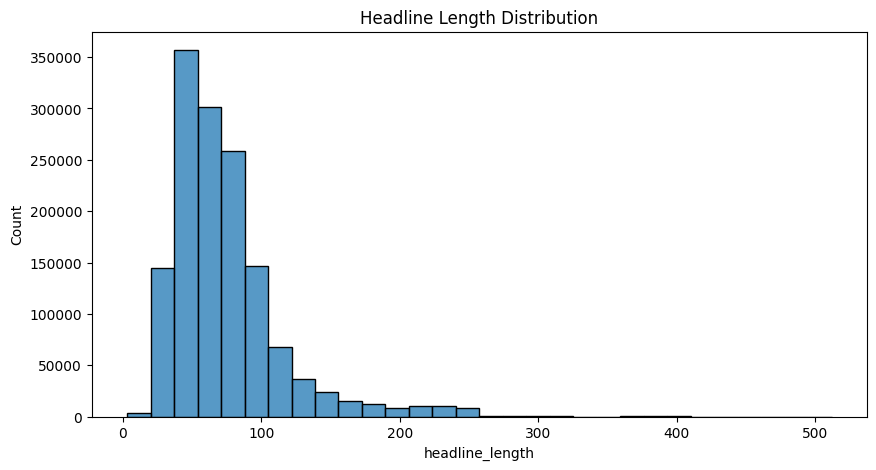

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=30)
plt.title("Headline Length Distribution")
plt.show()

## Interpretation

The histogram above illustrates the distribution of headline lengths across the financial news dataset.

Key observations include:

Most financial news headlines are concentrated between 40 and 100 characters, indicating that publishers prefer concise and information-dense headlines.
The distribution is right-skewed, meaning a small number of headlines are significantly longer than the majority.
The average headline length is approximately 73 characters, while the median is around 72 characters, suggesting a relatively balanced central tendency.
A few extreme outliers extend beyond 300–500 characters, which may represent unusually detailed headlines or formatting inconsistencies.
The relatively moderate standard deviation indicates that most headlines follow a consistent writing style and length pattern.

This analysis is important because headline structure can influence sentiment extraction quality and downstream NLP performance. Consistent headline lengths often improve vectorization and topic modeling effectiveness.

4. Publisher Analysis

In [8]:
publisher_counts = df['publisher'].value_counts().head(10)

publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Visualization:

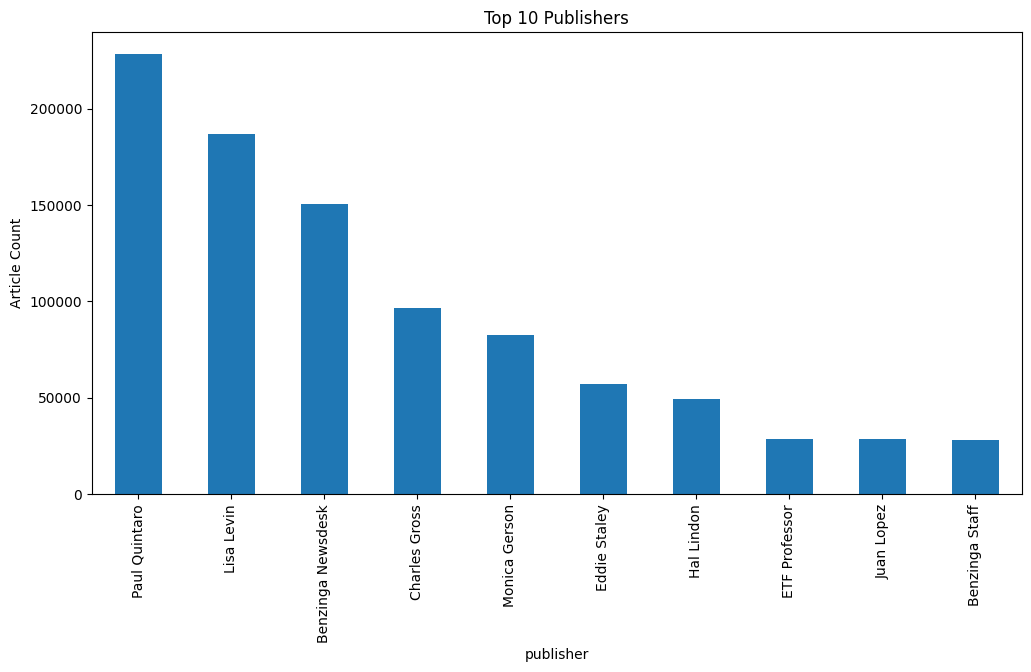

In [9]:
plt.figure(figsize=(12,6))
publisher_counts.plot(kind='bar')
plt.title("Top 10 Publishers")
plt.ylabel("Article Count")
plt.show()

### Publisher Analysis Interpretation

The bar chart displays the top 10 most active publishers in the financial news dataset based on the number of published articles.

Among all publishers, Paul Quintaro contributed the highest number of articles, followed by Lisa Levin and Benzinga Newsdesk. This indicates that a small group of publishers dominates the financial news coverage within the dataset.

The high concentration of articles from a few publishers suggests that these sources may significantly influence the overall sentiment trends observed in the analysis. Since publishers differ in writing style, focus areas, and reporting tone, publisher activity may also affect sentiment scoring and market perception.

Additionally, the dominance of financial media organizations such as Benzinga highlights the importance of real-time financial reporting platforms in shaping market narratives and investor sentiment.

This analysis provides useful context for later sentiment analysis because highly active publishers may contribute disproportionately to positive or negative market sentiment patterns.

5. Time Series Analysis of News Volume

## Convert dates:

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['date_only'] = df['date'].dt.date

## Articles per day:

In [12]:
daily_counts = df.groupby('date_only').size()

daily_counts.head()

date_only
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

Visualization:

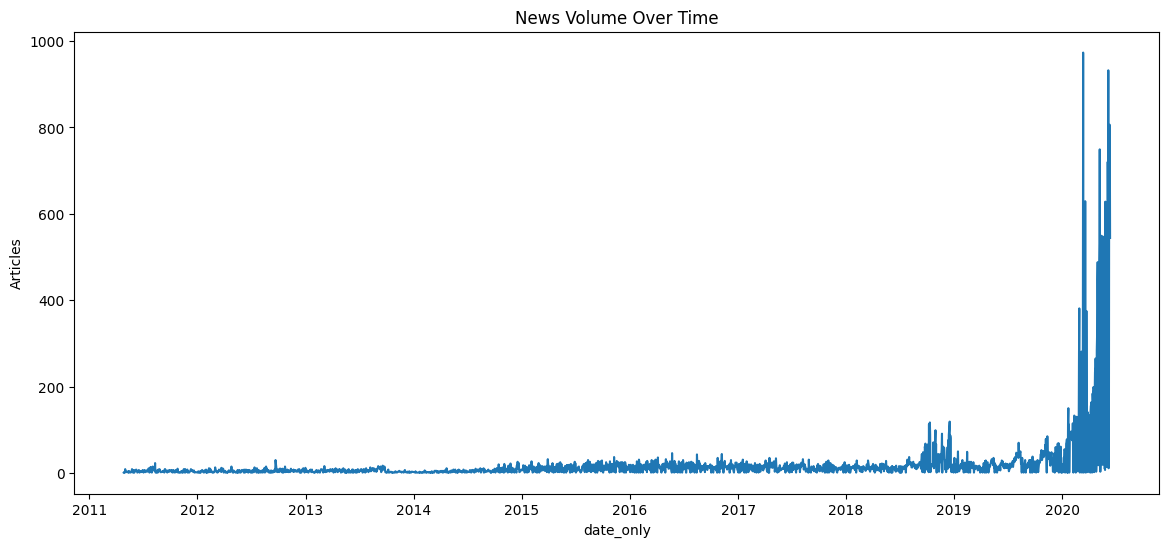

In [13]:
plt.figure(figsize=(14,6))
daily_counts.plot()
plt.title("News Volume Over Time")
plt.ylabel("Articles")
plt.show()

### Time Series Analysis Interpretation

The time series visualization illustrates how the volume of financial news articles changed over time from 2011 to 2020.

During the earlier years (2011–2014), the number of published articles remained relatively low and stable, indicating moderate news activity. Beginning around 2015, news publication frequency gradually increased, suggesting growing financial media coverage and market reporting activity.

A significant surge in article volume is observed between 2019 and 2020, where the dataset shows several major spikes reaching hundreds of articles per day. These spikes likely correspond to important market-moving events such as earnings seasons, economic uncertainty, major corporate announcements, or global financial disruptions.

The sharp increase in news activity toward 2020 indicates periods of heightened market attention and investor interest. High news volume periods are important because they may strongly influence market sentiment and stock price volatility.

This analysis provides valuable insight into how financial news intensity changes over time and helps identify periods where sentiment analysis may have the strongest relationship with stock market behavior.

6. Publishing Time Analysis

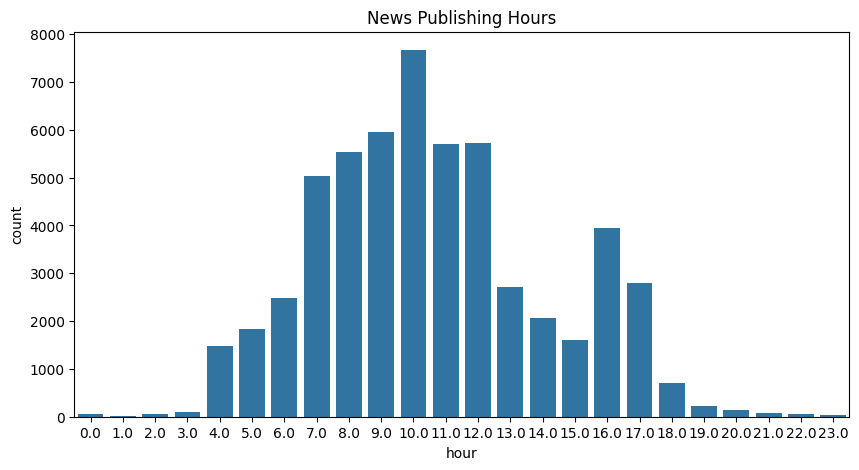

In [17]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)
plt.title("News Publishing Hours")
plt.show()

## Interpretation — News Publishing Hours

The distribution of publishing hours shows that most financial news articles are released during standard market activity hours, particularly between **7 AM and 12 PM**. The highest publishing frequency occurs around **10 AM**, indicating that publishers tend to release important financial updates shortly after market opening hours.

There is also a noticeable secondary spike around **4 PM

7. Keyword Analysis

## TF-IDF

In [18]:
tfidf = TfidfVectorizer(stop_words='english', max_features=20)

X = tfidf.fit_transform(df['headline'].astype(str))

words = tfidf.get_feature_names_out()

scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    'word': words,
    'score': scores
}).sort_values(by='score', ascending=False)

tfidf_df

,word,score
15,stocks,120048.420657
7,market,83037.704493
14,shares,77559.971297
4,earnings,75181.331827
18,vs,65464.128259
12,reports,64127.172118
17,update,63627.866238
1,benzinga,62142.509181
5,eps,61187.454960
0,announces,55964.729030


Visualization:

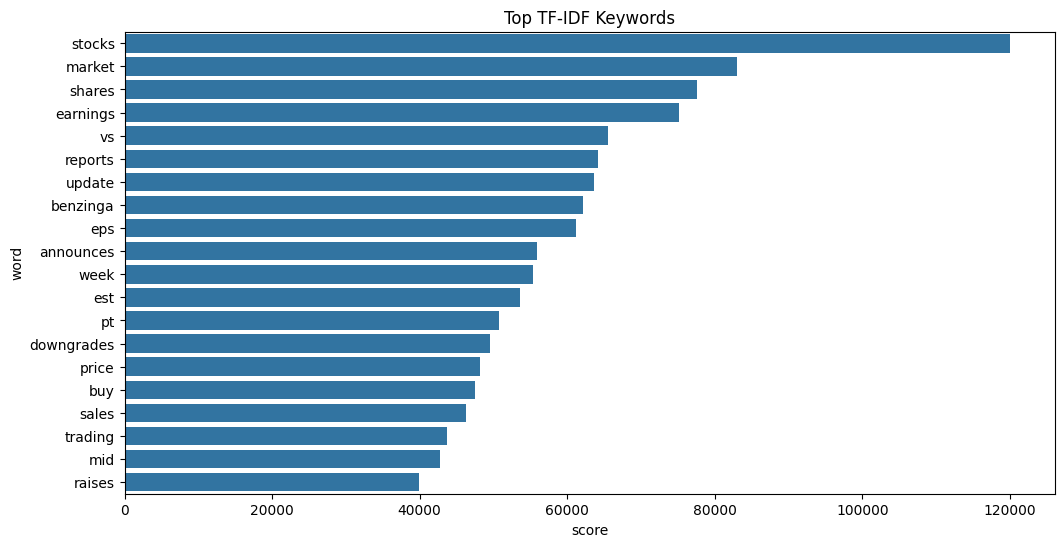

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(data=tfidf_df, x='score', y='word')
plt.title("Top TF-IDF Keywords")
plt.show()

### Keyword Analysis Interpretation

The TF-IDF analysis identifies the most important and frequently emphasized words appearing in the financial news headlines dataset.

Among all extracted keywords, the term “stocks” has the highest TF-IDF score, followed by words such as “market”, “shares”, “earnings”, and “reports”. This indicates that the dataset is strongly focused on stock market activity, corporate earnings announcements, trading updates, and financial performance reporting.

Several investment-related terms such as “buy”, “downgrades”, “price”, “raises”, and “EPS” (earnings per share) appear prominently, suggesting that analyst recommendations and company financial metrics are major themes in the news coverage.

The presence of words like “trading”, “sales”, and “market” further highlights the dataset’s emphasis on financial market movements and investor-related information. Additionally, the keyword “Benzinga” appears frequently because many articles originate from Benzinga financial news sources.

Overall, the keyword analysis reveals that the financial news headlines are highly concentrated around market performance, stock evaluations, earnings reports, and analyst actions. These recurring themes are likely to influence investor sentiment and may play an important role in predicting stock price movements during later sentiment and correlation analysis tasks.

8. WordCloud

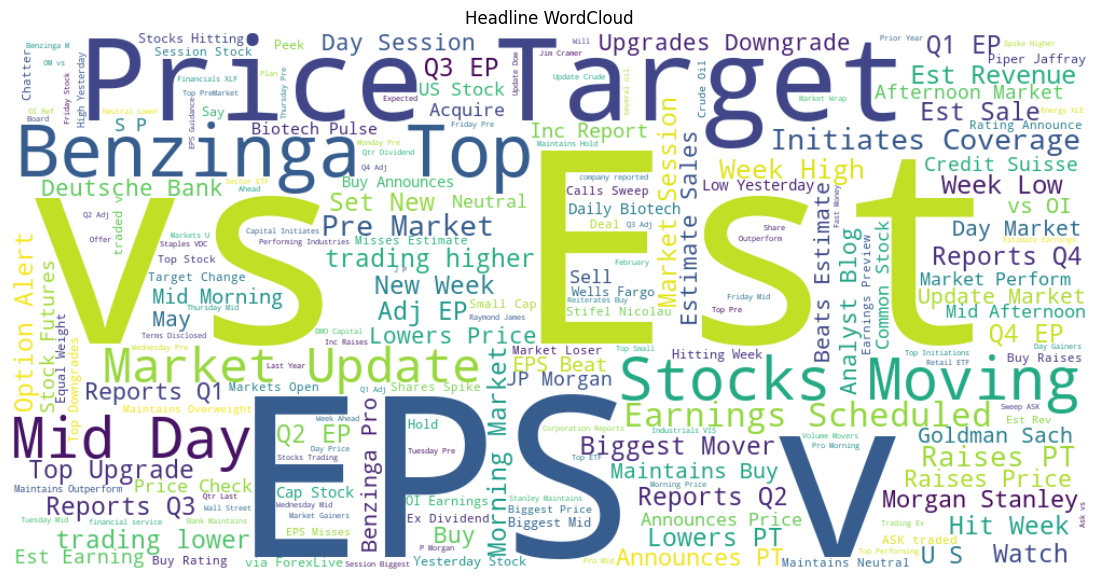

In [20]:
text = " ".join(df['headline'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Headline WordCloud")
plt.show()

## Interpretation — Headline WordCloud Visualization

The WordCloud visualization highlights the most frequently occurring words in financial news headlines. Larger words represent terms that appear more often throughout the dataset.

Key terms such as **"price target"**, **"stocks"**, **"market"**, **"earnings"**, **"moving"**, and **"Benzinga"** dominate the visualization, indicating that the dataset heavily focuses on stock market analysis, earnings reports, analyst ratings, and price movement discussions.

Words like **"raises"**, **"lowers"**, **"upgrades"**, **"downgrade"**, and **"initiates coverage"** suggest that analyst recommendations and rating changes are recurring themes in financial news reporting. Additionally, terms related to trading sessions such as **"mid day"**, **"pre market"**, and **"afternoon market"** indicate that many articles provide intraday market updates.

The WordCloud confirms that the dataset is strongly centered around market sentiment, stock performance, analyst actions, and earnings-related events, making it suitable for sentiment analysis and stock movement prediction tasks.

9. Publisher Domain Analysis

In [21]:
df['publisher_domain'] = df['publisher'].astype(str).str.extract(r'@([\w\.-]+)')

domain_counts = df['publisher_domain'].value_counts().head(10)

domain_counts

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

Visualization:

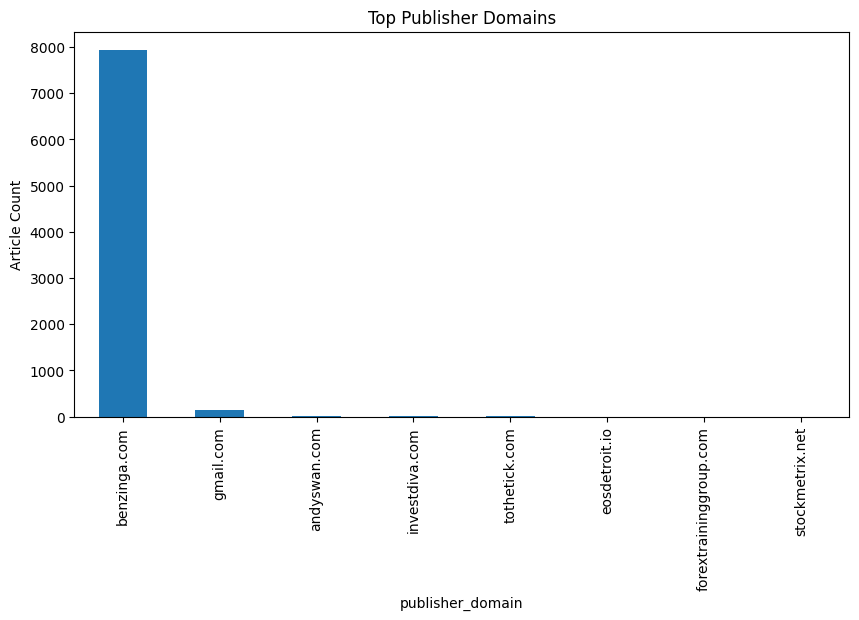

In [22]:
plt.figure(figsize=(10,5))
domain_counts.plot(kind='bar')

plt.title("Top Publisher Domains")
plt.ylabel("Article Count")

plt.show()

## Interpretation — Publisher Domain Analysis

The publisher domain analysis shows that **benzinga.com** is the dominant source of financial news in the dataset, contributing the overwhelming majority of articles. This indicates that the dataset is heavily influenced by Benzinga’s reporting style, coverage focus, and publishing frequency.

A much smaller number of articles come from domains such as **gmail.com**, **andyswan.com**, **investdiva.com**, and other independent sources. The presence of email-based domains suggests that some publishers may be individual contributors, analysts, or newsletter-style content creators rather than major financial media organizations.

The imbalance in publisher contribution indicates that sentiment patterns and topic trends in the dataset may primarily reflect the editorial behavior of a few dominant sources. This is important to consider during sentiment and correlation analysis because publisher bias or publishing frequency could influence the overall results.

# Key Insights / Conclusion

## Key Insights

1. The dataset contains a very large volume of financial news headlines collected over multiple years, providing a strong foundation for sentiment and market analysis.

2. Headline lengths are generally short and consistent, indicating that financial news headlines are written to deliver concise and high-impact information quickly.

3. Publisher analysis revealed that a small number of publishers dominate the dataset, particularly Benzinga, which contributes the majority of news articles.

4. Time-series analysis showed noticeable spikes in news publication volume during periods of major market activity, suggesting that financial news production increases during important economic or company events.

5. Publishing hour analysis demonstrated that most news articles are released during active market hours, especially in the morning trading session, when investors are most engaged.

6. TF-IDF keyword analysis identified common financial themes such as earnings reports, stock price targets, analyst upgrades/downgrades, trading activity, and market performance.

7. The WordCloud visualization further confirmed that the dataset is highly focused on stock movements, analyst opinions, earnings announcements, and market updates.

8. Publisher domain analysis showed that most articles originate from a few dominant financial media domains, which may influence the tone and distribution of news coverage.

---

## Conclusion

The exploratory data analysis provided a strong understanding of the structure, trends, and characteristics of the financial news dataset. The analysis revealed clear patterns in publishing behavior, frequently discussed financial topics, and news activity over time.

The dataset appears highly suitable for sentiment analysis and predictive modeling because it contains rich textual information closely related to stock market events and investor sentiment. The identified trends and recurring themes will support the next stages of the project, including sentiment scoring, technical indicator computation, and correlation analysis between financial news sentiment and stock price movements.

Overall, the findings suggest that financial news headlines contain valuable signals that may help explain or predict stock market behavior when combined with historical price data and quantitative analysis techniques.